# XGBoost Model Predicting Ridership

### Packages

In [14]:
# Data handling
import pandas as pd
import numpy as np

# Data reading
import requests
from io import StringIO

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import leafmap.foliumap as leafmap
import plotly.express as px

# Model requirements
from xgboost import XGBRegressor

# Model validation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import  mean_squared_error, r2_score, root_mean_squared_error


### Read the Clean Datasets

In [3]:
# Read the origin time series file into a DataFrame
url_ts = "https://raw.githubusercontent.com/iansargent/nyc-subway-ridership-ml/main/Data/Clean/origin_ridership_time_series_CLEAN.csv"
origin = pd.read_csv(StringIO(requests.get(url_ts, verify=False).text))

### Displaying the Dataset

In [12]:
origin.columns

Index(['month', 'day_of_week', 'hour_of_day', 'origin_station_complex_id',
       'origin_station_complex_name', 'origin_latitude', 'origin_longitude',
       'origin_point', 'sum_estimated_average_ridership', 'lag_1', 'lag_2',
       'lag_6', 'lag_24', 'roll_mean_3', 'roll_mean_6', 'roll_mean_24',
       'roll_std_3', 'roll_std_6', 'diff_1', 'pct_change_1', 'hour_sin',
       'hour_cos', 'month_sin', 'month_cos', 'is_peak'],
      dtype='object')

### Feature Engineering

In [7]:
# LAG FEATURES - Previous ridership values
origin['lag_1'] = origin['sum_estimated_average_ridership'].shift(1)
origin['lag_2'] = origin['sum_estimated_average_ridership'].shift(2)
origin['lag_6'] = origin['sum_estimated_average_ridership'].shift(6)
origin['lag_24'] = origin['sum_estimated_average_ridership'].shift(24)

# Average ridership in last X hours
origin['roll_mean_3'] = origin['sum_estimated_average_ridership'].rolling(3).mean()
origin['roll_mean_6'] = origin['sum_estimated_average_ridership'].rolling(6).mean()
origin['roll_mean_24'] = origin['sum_estimated_average_ridership'].rolling(24).mean()

# Standard deviation / variability in last X hours
origin['roll_std_3'] = origin['sum_estimated_average_ridership'].rolling(3).std()
origin['roll_std_6'] = origin['sum_estimated_average_ridership'].rolling(6).std()

# Hour-over-hour change/difference
origin['diff_1'] = origin['sum_estimated_average_ridership'].diff(1)
origin['pct_change_1'] = origin['sum_estimated_average_ridership'].pct_change(1)

# TIME OF DAY (CYCLICAL)
origin['hour_sin'] = np.sin(2 * np.pi * origin['hour_of_day'] / 24)
origin['hour_cos'] = np.cos(2 * np.pi * origin['hour_of_day'] / 24)

# MONTH CYCLICAL
origin['month_sin'] = np.sin(2 * np.pi * origin['month'] / 12)
origin['month_cos'] = np.cos(2 * np.pi * origin['month'] / 12)

# PEAK HOUR FLAGS
origin['is_peak'] = origin['hour_of_day'].isin([7, 8, 9, 17, 18, 19]).astype(int)

# Drop missing values
origin = origin.dropna()

### XGBoost Model

Train RMSE: 28.07
Train R²: 0.9983
Test RMSE: 39.41
Test R²: 0.9966
Axes(0.125,0.11;0.775x0.77)


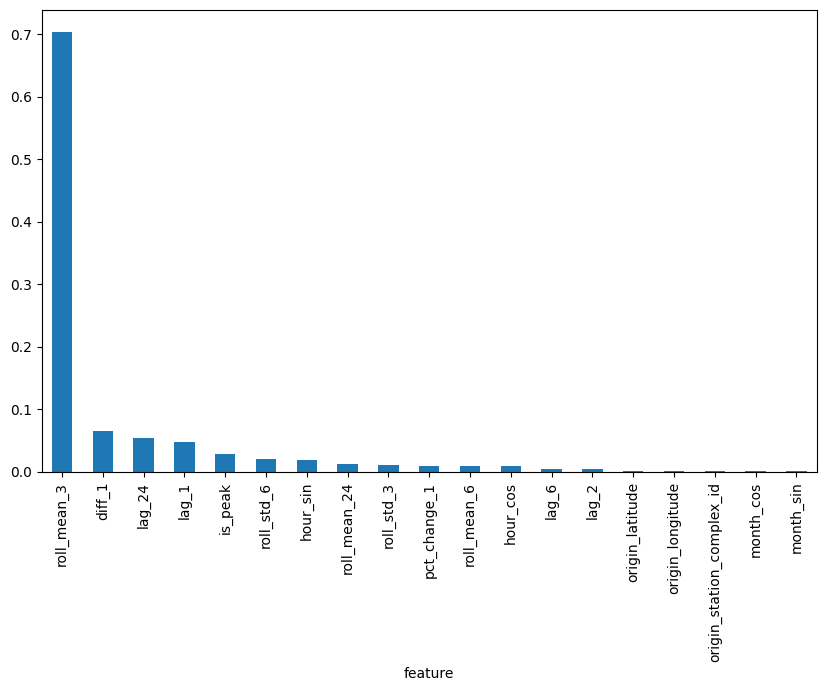

In [ ]:
import xgboost as xgb

# Split data
cols_to_drop = ['sum_estimated_average_ridership', 'day_of_week', 
                'hour_of_day', 'month', 'origin_point', 'origin_station_complex_name']
X = origin.drop(columns=cols_to_drop, axis=1)
y = origin['sum_estimated_average_ridership']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
model = xgb.XGBRegressor(random_state=3870)
model.fit(X_train, y_train)



### Evaluate Performance

In [ ]:
# Ridership predictions
y_pred = model.predict(X_test)
# Root mean squared error (RMSE)
rmse = root_mean_squared_error(y_test, y_pred)
# R-squared (R²)
r2 = r2_score(y_test, y_pred)

# Training performance (not really important)
print(f"Train RMSE: {root_mean_squared_error(y_train, model.predict(X_train)):.2f}")
print(f"Train R²: {r2_score(y_train, model.predict(X_train)):.4f}")

# Testing performance
print(f"Test RMSE: {rmse:.2f}")
print(f"Test R²: {r2:.4f}")

# Feature importance
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).plot(
    kind='bar', x='feature', y='importance', 
    legend=False, figsize=(10, 6)
)